In [ ]:
# Install packages required in a fresh Google Colab runtime.
# kagglehub downloads the public Kaggle dataset; transformers/datasets support fine-tuning.
!pip -q install -U "kagglehub>=0.3" "transformers>=4.41,<6" "datasets>=2.19,<5" "accelerate>=0.30,<2" "scikit-learn>=1.4" joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 90.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 95.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 14.9 MB/s eta 0:00:00


In [ ]:
# Core imports and experiment configuration.
import os
import re
import gc
import json
import time
import html
import random
import shutil
import warnings
from dataclasses import dataclass, asdict
from pathlib import Path
from contextlib import nullcontext

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import joblib
import kagglehub

from tqdm.auto import tqdm
from IPython.display import display
from torch.utils.data import DataLoader
from datasets import Dataset, DatasetDict

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    average_precision_score,
    precision_recall_curve,
    f1_score,
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    get_linear_schedule_with_warmup,
)

warnings.filterwarnings("ignore")


@dataclass(frozen=True)
class ExperimentConfig:
    seed: int = 42

    # Kaggle source
    kaggle_handle: str = "shivamb/real-or-fake-fake-jobposting-prediction"
    csv_filename: str = "fake_job_postings.csv"

    # Transformer
    model_name: str = "distilbert/distilbert-base-uncased"
    max_length: int = 256

    # Leakage-safe data split: approximately 70% train, 15% validation, 15% test
    validation_fraction: float = 0.15
    test_fraction: float = 0.15

    # Set max_rows to an integer only for a quick debugging run. Keep None for submission.
    max_rows: object = None

    # Final fine-tuning
    epochs: int = 3
    warmup_ratio: float = 0.10

    # Resource-aware hyperparameter tuning subsets
    tuning_train_size: int = 4000
    tuning_validation_size: int = 1000
    tuning_epochs: int = 1

    # Output locations in Colab
    output_dir: str = "/content/distilbert_fake_job_best"
    results_dir: str = "/content/fake_job_assignment_results"


CFG = ExperimentConfig()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = DEVICE.type == "cuda"


def set_seed(seed: int) -> None:
    """Set Python, NumPy and PyTorch seeds for reproducibility."""
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(CFG.seed)
Path(CFG.output_dir).mkdir(parents=True, exist_ok=True)
Path(CFG.results_dir).mkdir(parents=True, exist_ok=True)

print("Device:", DEVICE)
print("Mixed precision enabled:", USE_AMP)
print(json.dumps(asdict(CFG), indent=2))

if DEVICE.type != "cuda":
    print("\nWARNING: A GPU was not detected. In Colab select Runtime > Change runtime type > T4 GPU.")

Device: cuda
Mixed precision enabled: True
{
  "seed": 42,
  "kaggle_handle": "shivamb/real-or-fake-fake-jobposting-prediction",
  "csv_filename": "fake_job_postings.csv",
  "model_name": "distilbert/distilbert-base-uncased",
  "max_length": 256,
  "validation_fraction": 0.15,
  "test_fraction": 0.15,
  "max_rows": null,
  "epochs": 3,
  "warmup_ratio": 0.1,
  "tuning_train_size": 4000,
  "tuning_validation_size": 1000,
  "tuning_epochs": 1,
  "output_dir": "/content/distilbert_fake_job_best",
  "results_dir": "/content/fake_job_assignment_results"
}


## 1. Download and inspect the Kaggle data

The next cell downloads the public dataset automatically. A fallback upload option is included in case Kaggle access is temporarily unavailable.

In [ ]:
# Download the public Kaggle dataset and locate the CSV file.
def locate_dataset_csv() -> Path:
    """Download the Kaggle dataset and return the path to its CSV file."""
    try:
        dataset_directory = Path(
            kagglehub.dataset_download(CFG.kaggle_handle)
        )
        matches = list(dataset_directory.rglob(CFG.csv_filename))

        if not matches:
            csv_files = list(dataset_directory.rglob("*.csv"))
            if len(csv_files) == 1:
                matches = csv_files

        if not matches:
            raise FileNotFoundError(
                f"Could not find {CFG.csv_filename} inside {dataset_directory}."
            )

        return matches[0]

    except Exception as download_error:
        print("no file", download_error)
        print("Upload fake_job_postings.csv")
        from google.colab import files

        uploaded = files.upload()
        if not uploaded:
            raise RuntimeError("No CSV file was uploaded.")

        uploaded_name = next(iter(uploaded))
        return Path("/content") / uploaded_name


CSV_PATH = locate_dataset_csv()
raw_df = pd.read_csv(CSV_PATH)

print("CSV path:", CSV_PATH)
print("Raw shape:", raw_df.shape)
print("Columns:")
print(raw_df.columns.tolist())

display(raw_df.head(3))

100%|██████████| 16.1M/16.1M [00:01<00:00, 8.72MB/s]

Extracting files...


CSV path: /root/.cache/kagglehub/datasets/shivamb/real-or-fake-fake-jobposting-prediction/versions/1/fake_job_postings.csv
Raw shape: (17880, 18)
Columns:
['job_id', 'title', 'location', 'department', 'salary_range', 'company_profile', 'description', 'requirements', 'benefits', 'telecommuting', 'has_company_logo', 'has_questions', 'employment_type', 'required_experience', 'required_education', 'industry', 'function', 'fraudulent']


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0


In [ ]:
# Build one labelled text sequence per job advertisement.
TARGET_COLUMN = "fraudulent"
LABEL_NAMES = {0: "Real", 1: "Fraudulent"}

TEXT_FIELDS = [
    "title",
    "company_profile",
    "description",
    "requirements",
    "benefits",
    "location",
    "department",
    "employment_type",
    "required_experience",
    "required_education",
    "industry",
    "function",
]

FIELD_LABELS = {
    "title": "Title",
    "company_profile": "Company profile",
    "description": "Description",
    "requirements": "Requirements",
    "benefits": "Benefits",
    "location": "Location",
    "department": "Department",
    "employment_type": "Employment type",
    "required_experience": "Experience",
    "required_education": "Education",
    "industry": "Industry",
    "function": "Function",
}

missing_required = [
    column for column in [TARGET_COLUMN, *TEXT_FIELDS]
    if column not in raw_df.columns
]
if missing_required:
    raise ValueError(f"Required columns are missing: {missing_required}")


def clean_fragment(value) -> str:
    """Normalise one text fragment while preserving its linguistic content."""
    if pd.isna(value):
        return ""

    text = html.unescape(str(value))
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"https?://\S+|www\.\S+", " URL ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def combine_job_text(row: pd.Series) -> str:
    """Combine selected fields with readable field markers."""
    parts = []
    for field in TEXT_FIELDS:
        value = clean_fragment(row[field])
        if value:
            parts.append(f"{FIELD_LABELS[field]}: {value}")
    return " ".join(parts)


cleaned_df = raw_df.copy()
cleaned_df = cleaned_df.dropna(subset=[TARGET_COLUMN]).copy()
cleaned_df = cleaned_df[cleaned_df[TARGET_COLUMN].isin([0, 1])].copy()
cleaned_df["label"] = cleaned_df[TARGET_COLUMN].astype(int)
cleaned_df["text"] = cleaned_df.apply(combine_job_text, axis=1)
cleaned_df = cleaned_df[cleaned_df["text"].str.len() >= 30].copy()

rows_before_deduplication = len(cleaned_df)
cleaned_df = cleaned_df.drop_duplicates(subset="text").reset_index(drop=True)
removed_duplicates = rows_before_deduplication - len(cleaned_df)

if CFG.max_rows is not None and CFG.max_rows < len(cleaned_df):
    cleaned_df, _ = train_test_split(
        cleaned_df,
        train_size=int(CFG.max_rows),
        stratify=cleaned_df["label"],
        random_state=CFG.seed,
    )
    cleaned_df = cleaned_df.reset_index(drop=True)

cleaned_df["label_name"] = cleaned_df["label"].map(LABEL_NAMES)
cleaned_df["word_count"] = cleaned_df["text"].str.split().str.len()

print("Rows after cleaning:", f"{len(cleaned_df):,}")
print("Exact duplicate texts removed:", f"{removed_duplicates:,}")
print("Empty/invalid texts remaining:", int((cleaned_df["text"].str.len() == 0).sum()))

display(
    cleaned_df[["text", "label", "label_name", "word_count"]]
    .sample(min(5, len(cleaned_df)), random_state=CFG.seed)
)

Rows after cleaning: 17,532
Exact duplicate texts removed: 348
Empty/invalid texts remaining: 0


,text,label,label_name,word_count
15053,Title: English Teacher Abroad Company profile:...,0,Real,87
2512,Title: Medical Assistant Description: Back off...,0,Real,87
10679,Title: Shipper Company profile: Our HistoryFou...,0,Real,658
13688,Title: Senior SQL Developer Company profile: W...,0,Real,569
3014,"Title: Manager, Customer Support Company profi...",0,Real,941


## 3. Exploratory data analysis



,missing_percent
department,64.58
required_education,45.33
benefits,40.34
required_experience,39.43
function,36.10
industry,27.42
employment_type,19.41
company_profile,18.50
requirements,15.08
location,1.94


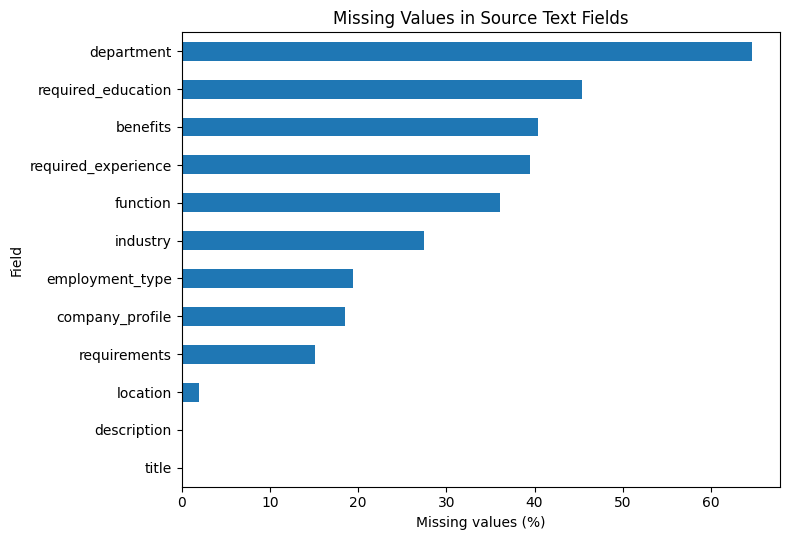

In [ ]:
# Missing-value analysis for the source fields used to construct the model text.
missing_summary = (
    raw_df[TEXT_FIELDS]
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .rename("missing_percent")
    .to_frame()
)

display(missing_summary.round(2))

ax = missing_summary.sort_values("missing_percent").plot(
    kind="barh",
    y="missing_percent",
    figsize=(8, 5.5),
    legend=False,
)
ax.set_title("Missing Values in Source Text Fields")
ax.set_xlabel("Missing values (%)")
ax.set_ylabel("Field")
plt.tight_layout()
plt.show()

,rows,percentage
class,,
Real,16677,95.12
Fraudulent,855,4.88


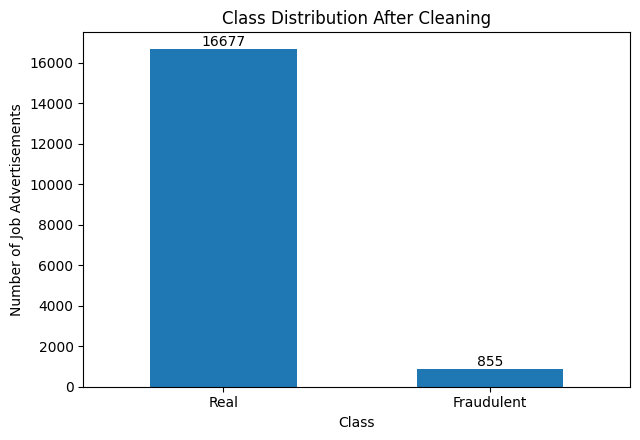

,count,mean,std,min,50%,75%,90%,95%,max
label_name,,,,,,,,,
Fraudulent,855.0,301.6,207.0,6.0,244.0,403.0,601.6,726.9,1356.0
Real,16677.0,398.9,208.1,11.0,376.0,516.0,668.0,781.2,2133.0


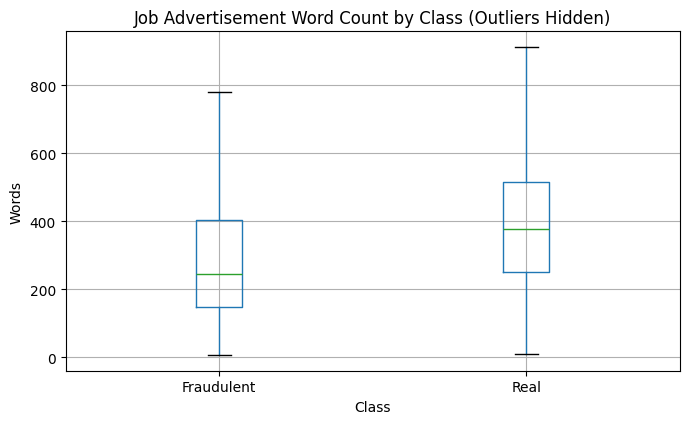

In [ ]:
# Class distribution and text-length summaries.
class_summary = (
    cleaned_df["label_name"]
    .value_counts()
    .rename_axis("class")
    .to_frame("rows")
)
class_summary["percentage"] = 100 * class_summary["rows"] / class_summary["rows"].sum()

display(class_summary.round(2))

ax = class_summary["rows"].plot(
    kind="bar",
    figsize=(6.5, 4.5),
    width=0.55,
)
ax.set_title("Class Distribution After Cleaning")
ax.set_xlabel("Class")
ax.set_ylabel("Number of Job Advertisements")
ax.tick_params(axis="x", rotation=0)
ax.bar_label(ax.containers[0])
plt.tight_layout()
plt.show()

length_summary = (
    cleaned_df.groupby("label_name")["word_count"]
    .describe(percentiles=[0.50, 0.75, 0.90, 0.95])
)
display(length_summary.round(1))

ax = cleaned_df.boxplot(
    column="word_count",
    by="label_name",
    showfliers=False,
    figsize=(7, 4.5),
)
plt.suptitle("")
ax.set_title("Job Advertisement Word Count by Class (Outliers Hidden)")
ax.set_xlabel("Class")
ax.set_ylabel("Words")
plt.tight_layout()
plt.show()

## 4. Leakage-safe train, validation and test split



In [ ]:
# Create approximately 70/15/15 stratified partitions.
train_validation_df, test_df = train_test_split(
    cleaned_df[["text", "label"]],
    test_size=CFG.test_fraction,
    stratify=cleaned_df["label"],
    random_state=CFG.seed,
)

relative_validation_fraction = (
    CFG.validation_fraction / (1.0 - CFG.test_fraction)
)

train_df, val_df = train_test_split(
    train_validation_df,
    test_size=relative_validation_fraction,
    stratify=train_validation_df["label"],
    random_state=CFG.seed,
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

# Leakage checks: exact combined text must be disjoint across all partitions.
assert set(train_df["text"]).isdisjoint(set(val_df["text"]))
assert set(train_df["text"]).isdisjoint(set(test_df["text"]))
assert set(val_df["text"]).isdisjoint(set(test_df["text"]))


def split_row(name: str, frame: pd.DataFrame) -> dict:
    fake_count = int((frame["label"] == 1).sum())
    return {
        "split": name,
        "rows": len(frame),
        "real": int((frame["label"] == 0).sum()),
        "fraudulent": fake_count,
        "fraudulent_percent": 100 * fake_count / len(frame),
    }


split_summary = pd.DataFrame([
    split_row("Train", train_df),
    split_row("Validation", val_df),
    split_row("Test", test_df),
])

display(split_summary.round(2))
print("Leakage checks passed: no exact combined text overlaps between splits.")

,split,rows,real,fraudulent,fraudulent_percent
0,Train,12272,11673,599,4.88
1,Validation,2630,2502,128,4.87
2,Test,2630,2502,128,4.87


Leakage checks passed: no exact combined text overlaps between splits.


## 5. Evaluation functions



In [ ]:
# Reusable metric and threshold-selection functions.
def calculate_metrics(
    y_true,
    y_pred,
    positive_probabilities=None,
) -> dict:
    """Calculate metrics plus imbalance-sensitive metrics."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    per_class_precision, per_class_recall, per_class_f1, _ = (
        precision_recall_fscore_support(
            y_true,
            y_pred,
            labels=[0, 1],
            average=None,
            zero_division=0,
        )
    )

    precision_macro, recall_macro, f1_macro, _ = (
        precision_recall_fscore_support(
            y_true,
            y_pred,
            average="macro",
            zero_division=0,
        )
    )

    _, _, f1_weighted, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0,
    )

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_real": per_class_precision[0],
        "recall_real": per_class_recall[0],
        "f1_real": per_class_f1[0],
        "precision_fraudulent": per_class_precision[1],
        "recall_fraudulent": per_class_recall[1],
        "f1_fraudulent": per_class_f1[1],
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
    }

    if positive_probabilities is not None and len(np.unique(y_true)) == 2:
        positive_probabilities = np.asarray(positive_probabilities)
        metrics["roc_auc"] = roc_auc_score(y_true, positive_probabilities)
        metrics["average_precision"] = average_precision_score(
            y_true,
            positive_probabilities,
        )

    return metrics


def tune_decision_threshold(
    y_true,
    positive_probabilities,
    thresholds=None,
):
    """Choose a validation threshold that maximises fraudulent-class F1."""
    if thresholds is None:
        thresholds = np.arange(0.05, 0.951, 0.01)

    rows = []
    for threshold in thresholds:
        predictions = (np.asarray(positive_probabilities) >= threshold).astype(int)
        metrics = calculate_metrics(y_true, predictions, positive_probabilities)
        rows.append({"threshold": threshold, **metrics})

    table = (
        pd.DataFrame(rows)
        .sort_values(
            ["f1_fraudulent", "f1_macro", "recall_fraudulent"],
            ascending=[False, False, False],
        )
        .reset_index(drop=True)
    )
    return float(table.loc[0, "threshold"]), table

## 6. Baseline: TF–IDF + Logistic Regression



In [ ]:
# Fit the TF-IDF representation only on the training set.
tfidf = TfidfVectorizer(
    lowercase=True,
    strip_accents="unicode",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.98,
    max_features=60_000,
    sublinear_tf=True,
)

X_train_tfidf = tfidf.fit_transform(train_df["text"])
X_val_tfidf = tfidf.transform(val_df["text"])
X_test_tfidf = tfidf.transform(test_df["text"])

baseline_c_values = [0.25, 0.5, 1.0, 2.0, 4.0]
baseline_tuning_rows = []
baseline_models = {}

for c_value in baseline_c_values:
    candidate = LogisticRegression(
        C=c_value,
        max_iter=2000,
        class_weight="balanced",
        solver="liblinear",
        random_state=CFG.seed,
    )
    candidate.fit(X_train_tfidf, train_df["label"])

    validation_probabilities = candidate.predict_proba(X_val_tfidf)[:, 1]
    validation_predictions = (validation_probabilities >= 0.5).astype(int)
    metrics = calculate_metrics(
        val_df["label"],
        validation_predictions,
        validation_probabilities,
    )

    baseline_tuning_rows.append({"C": c_value, **metrics})
    baseline_models[c_value] = candidate

baseline_tuning = (
    pd.DataFrame(baseline_tuning_rows)
    .sort_values(
        ["f1_macro", "f1_fraudulent", "average_precision"],
        ascending=[False, False, False],
    )
    .reset_index(drop=True)
)

best_c = float(baseline_tuning.loc[0, "C"])
baseline_model = baseline_models[best_c]

display(baseline_tuning.round(4))
print("Selected Logistic Regression C:", best_c)

,C,accuracy,precision_real,recall_real,f1_real,precision_fraudulent,recall_fraudulent,f1_fraudulent,precision_macro,recall_macro,f1_macro,f1_weighted,roc_auc,average_precision
0,4.00,0.9886,0.9936,0.9944,0.9940,0.8889,0.8750,0.8819,0.9412,0.9347,0.9379,0.9886,0.9921,0.9366
1,2.00,0.9867,0.9940,0.9920,0.9930,0.8496,0.8828,0.8659,0.9218,0.9374,0.9294,0.9868,0.9917,0.9325
2,1.00,0.9821,0.9940,0.9872,0.9906,0.7793,0.8828,0.8278,0.8866,0.9350,0.9092,0.9827,0.9909,0.9254
3,0.50,0.9779,0.9931,0.9836,0.9884,0.7303,0.8672,0.7929,0.8617,0.9254,0.8906,0.9788,0.9899,0.9168
4,0.25,0.9730,0.9931,0.9784,0.9857,0.6727,0.8672,0.7577,0.8329,0.9228,0.8717,0.9746,0.9882,0.9054


Selected Logistic Regression C: 4.0


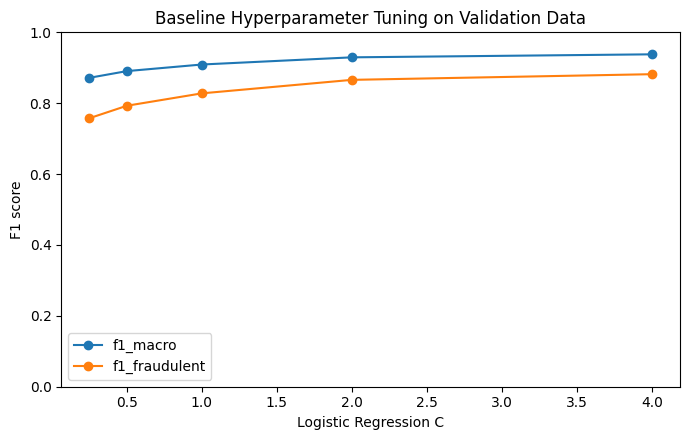

In [ ]:
# Visual evidence for baseline hyperparameter selection.
plot_data = baseline_tuning.sort_values("C")
ax = plot_data.plot(
    x="C",
    y=["f1_macro", "f1_fraudulent"],
    marker="o",
    figsize=(7, 4.5),
)
ax.set_title("Baseline Hyperparameter Tuning on Validation Data")
ax.set_xlabel("Logistic Regression C")
ax.set_ylabel("F1 score")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## 7. BERT tokenisation and truncation analysis




config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Measuring token lengths:   0%|          | 0/1000 [00:00<?, ?it/s]

,token_count
count,1000.0
mean,586.6
std,302.3
min,69.0
50%,537.5
75%,754.2
90%,996.3
95%,1129.6
max,2544.0


Sample above max_length=256: 88.00%


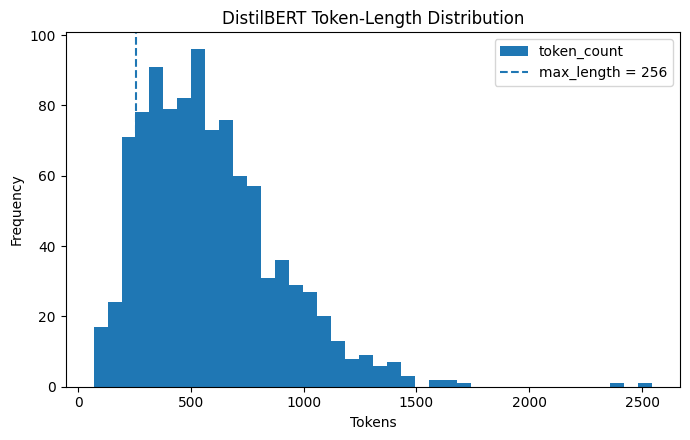

In [ ]:
# Load the pretrained DistilBERT tokenizer and measure token lengths.
tokenizer = AutoTokenizer.from_pretrained(
    CFG.model_name,
    use_fast=True,
)

length_sample = train_df.sample(
    n=min(1000, len(train_df)),
    random_state=CFG.seed,
).copy()

token_lengths = []
for text in tqdm(length_sample["text"], desc="Measuring token lengths"):
    token_lengths.append(
        len(
            tokenizer(
                text,
                add_special_tokens=True,
                truncation=False,
                verbose=False,
            )["input_ids"]
        )
    )

length_sample["token_count"] = token_lengths
token_length_summary = length_sample["token_count"].describe(
    percentiles=[0.50, 0.75, 0.90, 0.95]
)
truncated_percentage = 100 * (
    length_sample["token_count"] > CFG.max_length
).mean()

display(token_length_summary.round(1))
print(
    f"Sample above max_length={CFG.max_length}: "
    f"{truncated_percentage:.2f}%"
)

ax = length_sample["token_count"].plot(
    kind="hist",
    bins=40,
    figsize=(7, 4.5),
)
ax.axvline(
    CFG.max_length,
    linestyle="--",
    label=f"max_length = {CFG.max_length}",
)
ax.set_title("DistilBERT Token-Length Distribution")
ax.set_xlabel("Tokens")
ax.set_ylabel("Frequency")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Convert data to Hugging Face datasets and create dynamic batches



In [ ]:
# Convert pandas DataFrames to tokenised Hugging Face datasets.
def frame_to_dataset(frame: pd.DataFrame) -> Dataset:
    dataset = Dataset.from_pandas(
        frame[["text", "label"]],
        preserve_index=False,
    )
    return dataset.rename_column("label", "labels")


def tokenise_batch(batch: dict) -> dict:
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=CFG.max_length,
    )


text_datasets = DatasetDict({
    "train": frame_to_dataset(train_df),
    "validation": frame_to_dataset(val_df),
    "test": frame_to_dataset(test_df),
})

tokenised_datasets = text_datasets.map(
    tokenise_batch,
    batched=True,
    remove_columns=["text"],
    desc="Tokenising fake-job data",
)

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    return_tensors="pt",
)


def make_loader(
    dataset,
    batch_size: int,
    shuffle: bool,
    seed: int = CFG.seed,
) -> DataLoader:
    """Create a reproducible dynamically padded PyTorch DataLoader."""
    generator = torch.Generator()
    generator.manual_seed(seed)

    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        collate_fn=data_collator,
        pin_memory=USE_AMP,
        num_workers=0,
        generator=generator,
    )


example_loader = make_loader(
    tokenised_datasets["train"],
    batch_size=8,
    shuffle=True,
)
example_batch = next(iter(example_loader))
print({name: tuple(tensor.shape) for name, tensor in example_batch.items()})

Tokenising fake-job data:   0%|          | 0/12272 [00:00<?, ? examples/s]

Tokenising fake-job data:   0%|          | 0/2630 [00:00<?, ? examples/s]

Tokenising fake-job data:   0%|          | 0/2630 [00:00<?, ? examples/s]

{'labels': (8,), 'input_ids': (8, 256), 'token_type_ids': (8, 256), 'attention_mask': (8, 256)}


In [ ]:
# Inspect architecture and calculate class weights using only training labels.
inspection_model = AutoModelForSequenceClassification.from_pretrained(
    CFG.model_name,
    num_labels=2,
)
model_config = inspection_model.config

architecture_summary = pd.DataFrame({
    "property": [
        "Model",
        "Transformer layers",
        "Hidden size",
        "Attention heads",
        "Vocabulary size",
        "Maximum positions",
        "Number of labels",
        "Trainable parameters",
    ],
    "value": [
        CFG.model_name,
        getattr(model_config, "n_layers", "Not available"),
        getattr(model_config, "dim", "Not available"),
        getattr(model_config, "n_heads", "Not available"),
        getattr(model_config, "vocab_size", "Not available"),
        getattr(model_config, "max_position_embeddings", "Not available"),
        2,
        sum(
            parameter.numel()
            for parameter in inspection_model.parameters()
            if parameter.requires_grad
        ),
    ],
})

display(architecture_summary)

del inspection_model
gc.collect()

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=train_df["label"].to_numpy(),
)
CLASS_WEIGHTS = torch.tensor(
    class_weights_array,
    dtype=torch.float32,
    device=DEVICE,
)

print("Class weights [real, fraudulent]:", class_weights_array)

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


,property,value
0,Model,distilbert/distilbert-base-uncased
1,Transformer layers,6
2,Hidden size,768
3,Attention heads,12
4,Vocabulary size,30522
5,Maximum positions,512
6,Number of labels,2
7,Trainable parameters,66955010


Class weights [real, fraudulent]: [ 0.5256575  10.24373957]


## 10. Reusable PyTorch training and evaluation routines



In [ ]:
# Model construction and one-epoch train/evaluation routine.
ID2LABEL = {0: "REAL", 1: "FRAUDULENT"}
LABEL2ID = {"REAL": 0, "FRAUDULENT": 1}


def create_training_objects(
    learning_rate: float,
    weight_decay: float,
    epochs: int,
    training_loader: DataLoader,
):
    """Create a fresh model, weighted loss, AdamW, scheduler and AMP scaler."""
    model = AutoModelForSequenceClassification.from_pretrained(
        CFG.model_name,
        num_labels=2,
        id2label=ID2LABEL,
        label2id=LABEL2ID,
    ).to(DEVICE)

    criterion = torch.nn.CrossEntropyLoss(weight=CLASS_WEIGHTS)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay,
    )

    total_steps = max(1, len(training_loader) * epochs)
    warmup_steps = int(total_steps * CFG.warmup_ratio)
    scheduler = get_linear_schedule_with_warmup(
        optimizer=optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps,
    )
    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

    return (
        model,
        criterion,
        optimizer,
        scheduler,
        scaler,
        total_steps,
        warmup_steps,
    )


def run_epoch(
    model,
    loader,
    criterion,
    optimizer=None,
    scheduler=None,
    scaler=None,
    description="Epoch",
):
    """Run one training or evaluation epoch and return loss, metrics and predictions."""
    is_training = optimizer is not None
    model.train() if is_training else model.eval()

    total_loss = 0.0
    all_labels = []
    all_predictions = []
    all_probabilities = []

    progress = tqdm(loader, desc=description, leave=False)

    for batch in progress:
        labels = batch["labels"].to(DEVICE, non_blocking=USE_AMP)

        model_inputs = {
            key: value.to(DEVICE, non_blocking=USE_AMP)
            for key, value in batch.items()
            if key in {"input_ids", "attention_mask"}
        }

        if is_training:
            optimizer.zero_grad(set_to_none=True)

        gradient_context = torch.enable_grad() if is_training else torch.no_grad()
        autocast_context = (
            torch.autocast(device_type="cuda", dtype=torch.float16)
            if USE_AMP
            else nullcontext()
        )

        with gradient_context:
            with autocast_context:
                outputs = model(**model_inputs)
                logits = outputs.logits
                loss = criterion(logits, labels)

        if is_training:
            if USE_AMP:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            scheduler.step()

        probabilities = torch.softmax(logits.detach(), dim=1)[:, 1]
        predictions = torch.argmax(logits.detach(), dim=1)

        batch_size = labels.size(0)
        total_loss += loss.detach().item() * batch_size
        all_labels.extend(labels.detach().cpu().tolist())
        all_predictions.extend(predictions.cpu().tolist())
        all_probabilities.extend(probabilities.cpu().tolist())

        progress.set_postfix(loss=f"{loss.detach().item():.4f}")

    metrics = calculate_metrics(
        all_labels,
        all_predictions,
        all_probabilities,
    )

    return {
        "loss": total_loss / len(loader.dataset),
        **metrics,
        "labels": np.asarray(all_labels),
        "predictions": np.asarray(all_predictions),
        "probabilities": np.asarray(all_probabilities),
    }

## 11. DistilBERT hyperparameter tuning



In [ ]:
# Resource-aware, reproducible tuning subsets and candidate configurations.
tuning_candidates = [
    {"learning_rate": 2e-5, "batch_size": 16, "weight_decay": 0.01},
    {"learning_rate": 3e-5, "batch_size": 16, "weight_decay": 0.01},
    {"learning_rate": 2e-5, "batch_size": 8, "weight_decay": 0.01},
    {"learning_rate": 2e-5, "batch_size": 16, "weight_decay": 0.10},
]


def stratified_indices(labels, sample_size: int, seed: int):
    """Return reproducible indices retaining the original class ratio."""
    labels = np.asarray(labels)
    all_indices = np.arange(len(labels))

    if sample_size >= len(labels):
        return all_indices

    selected_indices, _ = train_test_split(
        all_indices,
        train_size=sample_size,
        stratify=labels,
        random_state=seed,
    )
    return np.sort(selected_indices)


tuning_train_indices = stratified_indices(
    train_df["label"],
    min(CFG.tuning_train_size, len(train_df)),
    CFG.seed,
)
tuning_validation_indices = stratified_indices(
    val_df["label"],
    min(CFG.tuning_validation_size, len(val_df)),
    CFG.seed,
)

tuning_train_dataset = tokenised_datasets["train"].select(
    tuning_train_indices.tolist()
)
tuning_validation_dataset = tokenised_datasets["validation"].select(
    tuning_validation_indices.tolist()
)

print("Tuning train rows:", len(tuning_train_dataset))
print("Tuning validation rows:", len(tuning_validation_dataset))

Tuning train rows: 4000
Tuning validation rows: 1000


In [ ]:
# Execute the DistilBERT hyperparameter trials.
tuning_rows = []

for trial_number, params in enumerate(tuning_candidates, start=1):
    print("\n" + "=" * 72)
    print(f"Hyperparameter trial {trial_number}/{len(tuning_candidates)}")
    print(params)
    print("=" * 72)

    set_seed(CFG.seed + trial_number)

    trial_train_loader = make_loader(
        tuning_train_dataset,
        batch_size=params["batch_size"],
        shuffle=True,
        seed=CFG.seed + trial_number,
    )
    trial_validation_loader = make_loader(
        tuning_validation_dataset,
        batch_size=params["batch_size"] * 2,
        shuffle=False,
        seed=CFG.seed,
    )

    (
        trial_model,
        trial_criterion,
        trial_optimizer,
        trial_scheduler,
        trial_scaler,
        total_steps,
        warmup_steps,
    ) = create_training_objects(
        learning_rate=params["learning_rate"],
        weight_decay=params["weight_decay"],
        epochs=CFG.tuning_epochs,
        training_loader=trial_train_loader,
    )

    trial_start = time.time()
    train_result = None

    for tuning_epoch in range(1, CFG.tuning_epochs + 1):
        train_result = run_epoch(
            model=trial_model,
            loader=trial_train_loader,
            criterion=trial_criterion,
            optimizer=trial_optimizer,
            scheduler=trial_scheduler,
            scaler=trial_scaler,
            description=(
                f"Trial {trial_number} training "
                f"{tuning_epoch}/{CFG.tuning_epochs}"
            ),
        )

    validation_result = run_epoch(
        model=trial_model,
        loader=trial_validation_loader,
        criterion=trial_criterion,
        description=f"Trial {trial_number} validation",
    )

    tuning_rows.append({
        "trial": trial_number,
        **params,
        "training_steps": total_steps,
        "warmup_steps": warmup_steps,
        "train_loss": train_result["loss"],
        "validation_loss": validation_result["loss"],
        "validation_accuracy": validation_result["accuracy"],
        "validation_precision_fraudulent": validation_result[
            "precision_fraudulent"
        ],
        "validation_recall_fraudulent": validation_result[
            "recall_fraudulent"
        ],
        "validation_f1_fraudulent": validation_result["f1_fraudulent"],
        "validation_f1_macro": validation_result["f1_macro"],
        "validation_average_precision": validation_result[
            "average_precision"
        ],
        "minutes": (time.time() - trial_start) / 60,
    })

    del (
        trial_model,
        trial_criterion,
        trial_optimizer,
        trial_scheduler,
        trial_scaler,
        trial_train_loader,
        trial_validation_loader,
    )
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

transformer_tuning = (
    pd.DataFrame(tuning_rows)
    .sort_values(
        [
            "validation_f1_macro",
            "validation_f1_fraudulent",
            "validation_average_precision",
            "validation_loss",
        ],
        ascending=[False, False, False, True],
    )
    .reset_index(drop=True)
)

best_transformer_params = {
    "learning_rate": float(transformer_tuning.loc[0, "learning_rate"]),
    "batch_size": int(transformer_tuning.loc[0, "batch_size"]),
    "weight_decay": float(transformer_tuning.loc[0, "weight_decay"]),
}

display(transformer_tuning.round(4))
print("\nSelected DistilBERT hyperparameters:")
print(json.dumps(best_transformer_params, indent=2))


Hyperparameter trial 1/4
{'learning_rate': 2e-05, 'batch_size': 16, 'weight_decay': 0.01}


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trial 1 training 1/1:   0%|          | 0/250 [00:00<?, ?it/s]

Trial 1 validation:   0%|          | 0/32 [00:00<?, ?it/s]

...

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trial 4 training 1/1:   0%|          | 0/250 [00:00<?, ?it/s]

Trial 4 validation:   0%|          | 0/32 [00:00<?, ?it/s]

,trial,learning_rate,batch_size,weight_decay,training_steps,warmup_steps,train_loss,validation_loss,validation_accuracy,validation_precision_fraudulent,validation_recall_fraudulent,validation_f1_fraudulent,validation_f1_macro,validation_average_precision,minutes
0,2,0.0,16,0.01,250,25,0.5771,0.4121,0.950,0.4935,0.7755,0.6032,0.7882,0.5658,0.5810
1,4,0.0,16,0.10,250,25,0.6702,0.6109,0.941,0.4000,0.4082,0.4040,0.6865,0.4630,0.6079
2,3,0.0,8,0.01,500,50,0.7459,0.7214,0.956,0.6316,0.2449,0.3529,0.6651,0.5125,0.8994
3,1,0.0,16,0.01,250,25,0.6356,0.9651,0.945,0.4167,0.3061,0.3529,0.6621,0.3985,0.5449



Selected DistilBERT hyperparameters:
{
  "learning_rate": 3e-05,
  "batch_size": 16,
  "weight_decay": 0.01
}


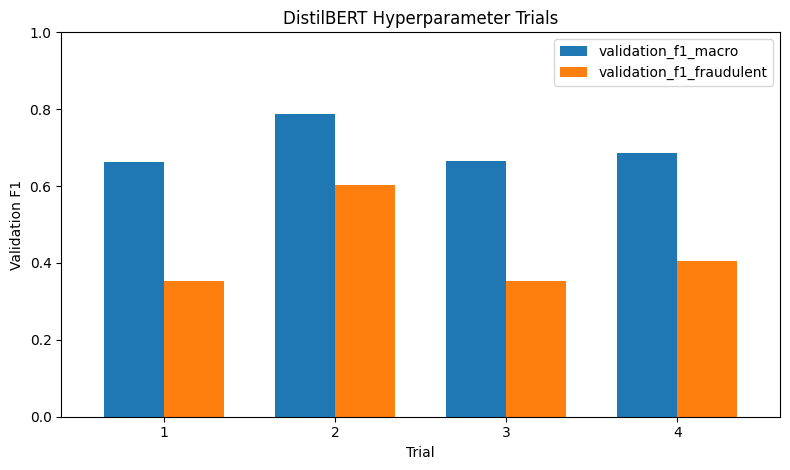

In [ ]:
# Plot the principal validation metrics for all Transformer trials.
tuning_plot = transformer_tuning.sort_values("trial").set_index("trial")
ax = tuning_plot[
    ["validation_f1_macro", "validation_f1_fraudulent"]
].plot(
    kind="bar",
    figsize=(8, 4.8),
    width=0.7,
)
ax.set_title("DistilBERT Hyperparameter Trials")
ax.set_xlabel("Trial")
ax.set_ylabel("Validation F1")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

## 12. Final DistilBERT fine-tuning and validation checkpoint selection


In [ ]:
# Create final loaders and a fresh model using the selected hyperparameters.
set_seed(CFG.seed)
selected_batch_size = best_transformer_params["batch_size"]

train_loader = make_loader(
    tokenised_datasets["train"],
    batch_size=selected_batch_size,
    shuffle=True,
    seed=CFG.seed,
)
val_loader = make_loader(
    tokenised_datasets["validation"],
    batch_size=selected_batch_size * 2,
    shuffle=False,
    seed=CFG.seed,
)
test_loader = make_loader(
    tokenised_datasets["test"],
    batch_size=selected_batch_size * 2,
    shuffle=False,
    seed=CFG.seed,
)

(
    model,
    criterion,
    optimizer,
    scheduler,
    scaler,
    total_training_steps,
    warmup_steps,
) = create_training_objects(
    learning_rate=best_transformer_params["learning_rate"],
    weight_decay=best_transformer_params["weight_decay"],
    epochs=CFG.epochs,
    training_loader=train_loader,
)

print("Final training configuration:")
print(json.dumps(best_transformer_params, indent=2))
print("Epochs:", CFG.epochs)
print("Training steps:", total_training_steps)
print("Warm-up steps:", warmup_steps)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Final training configuration:
{
  "learning_rate": 3e-05,
  "batch_size": 16,
  "weight_decay": 0.01
}
Epochs: 3
Training steps: 2301
Warm-up steps: 230


In [ ]:
# Fine-tune and save the checkpoint with the best validation macro F1.
history = []
best_validation_macro_f1 = -np.inf
best_epoch = None
training_start = time.time()

for epoch in range(1, CFG.epochs + 1):
    train_result = run_epoch(
        model=model,
        loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        scheduler=scheduler,
        scaler=scaler,
        description=f"Training {epoch}/{CFG.epochs}",
    )

    validation_result = run_epoch(
        model=model,
        loader=val_loader,
        criterion=criterion,
        description=f"Validation {epoch}/{CFG.epochs}",
    )

    history.append({
        "epoch": epoch,
        "train_loss": train_result["loss"],
        "train_accuracy": train_result["accuracy"],
        "train_f1_macro": train_result["f1_macro"],
        "train_f1_fraudulent": train_result["f1_fraudulent"],
        "validation_loss": validation_result["loss"],
        "validation_accuracy": validation_result["accuracy"],
        "validation_f1_macro": validation_result["f1_macro"],
        "validation_f1_fraudulent": validation_result["f1_fraudulent"],
        "validation_average_precision": validation_result[
            "average_precision"
        ],
    })

    print(
        f"Epoch {epoch}: "
        f"train loss={train_result['loss']:.4f}, "
        f"validation loss={validation_result['loss']:.4f}, "
        f"validation macro F1={validation_result['f1_macro']:.4f}, "
        f"fraudulent F1={validation_result['f1_fraudulent']:.4f}"
    )

    if validation_result["f1_macro"] > best_validation_macro_f1:
        best_validation_macro_f1 = validation_result["f1_macro"]
        best_epoch = epoch
        model.save_pretrained(CFG.output_dir)
        tokenizer.save_pretrained(CFG.output_dir)

elapsed_minutes = (time.time() - training_start) / 60

print(f"\nBest epoch: {best_epoch}")
print(f"Best validation macro F1: {best_validation_macro_f1:.4f}")
print(f"Final fine-tuning time: {elapsed_minutes:.1f} minutes")
print("Checkpoint:", CFG.output_dir)

best_model = AutoModelForSequenceClassification.from_pretrained(
    CFG.output_dir
).to(DEVICE)
best_model.eval()

Training 1/3:   0%|          | 0/767 [00:00<?, ?it/s]

Validation 1/3:   0%|          | 0/83 [00:00<?, ?it/s]

Epoch 1: train loss=0.5339, validation loss=0.2817, validation macro F1=0.9131, fraudulent F1=0.8346


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training 2/3:   0%|          | 0/767 [00:00<?, ?it/s]

...

Epoch 3: train loss=0.0970, validation loss=0.3664, validation macro F1=0.9331, fraudulent F1=0.8724


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Best epoch: 3
Best validation macro F1: 0.9331
Final fine-tuning time: 5.7 minutes
Checkpoint: /content/distilbert_fake_job_best


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


## 13. Learning curves and overfitting interpretation


,epoch,train_loss,train_accuracy,train_f1_macro,train_f1_fraudulent,validation_loss,validation_accuracy,validation_f1_macro,validation_f1_fraudulent,validation_average_precision
0,1,0.5339,0.9474,0.7292,0.4861,0.2817,0.9840,0.9131,0.8346,0.8872
1,2,0.2332,0.9869,0.9270,0.8608,0.2285,0.9859,0.9238,0.8549,0.9196
2,3,0.0970,0.9949,0.9724,0.9475,0.3664,0.9882,0.9331,0.8724,0.9238


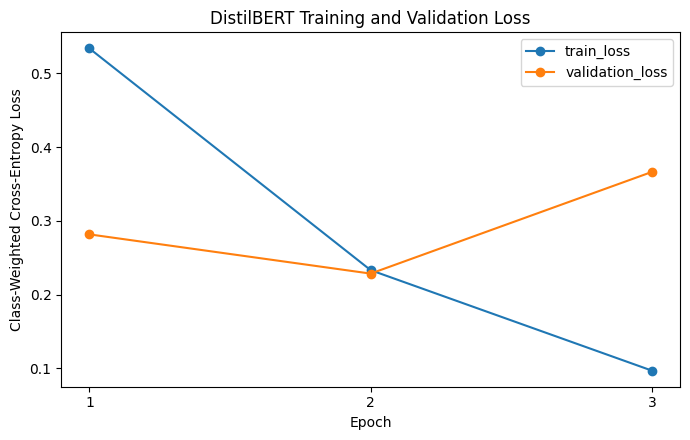

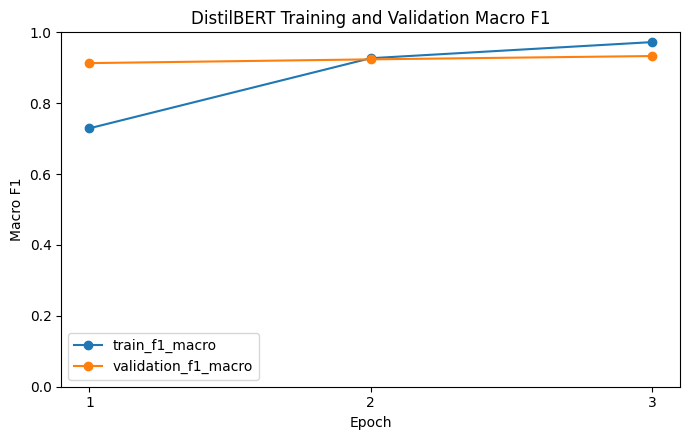

Interpretation: training loss continued to decrease after the minimum validation loss, which is evidence of possible overfitting. The saved checkpoint is selected by validation macro F1 rather than automatically using the final epoch.
Minimum validation-loss epoch: 2
Maximum validation macro-F1 epoch: 3


In [ ]:
# Plot learning curves and print a data-driven overfitting note.
history_df = pd.DataFrame(history)
display(history_df.round(4))

ax = history_df.plot(
    x="epoch",
    y=["train_loss", "validation_loss"],
    marker="o",
    figsize=(7, 4.5),
)
ax.set_title("DistilBERT Training and Validation Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Class-Weighted Cross-Entropy Loss")
ax.set_xticks(history_df["epoch"])
plt.tight_layout()
plt.show()

ax = history_df.plot(
    x="epoch",
    y=["train_f1_macro", "validation_f1_macro"],
    marker="o",
    figsize=(7, 4.5),
)
ax.set_title("DistilBERT Training and Validation Macro F1")
ax.set_xlabel("Epoch")
ax.set_ylabel("Macro F1")
ax.set_ylim(0, 1)
ax.set_xticks(history_df["epoch"])
plt.tight_layout()
plt.show()

minimum_validation_loss_epoch = int(
    history_df.loc[history_df["validation_loss"].idxmin(), "epoch"]
)
maximum_validation_f1_epoch = int(
    history_df.loc[history_df["validation_f1_macro"].idxmax(), "epoch"]
)

if (
    history_df.iloc[-1]["train_loss"] < history_df.iloc[0]["train_loss"]
    and history_df.iloc[-1]["validation_loss"]
    > history_df["validation_loss"].min()
):
    print(
        "Interpretation: training loss continued to decrease after the minimum ")
else:
    print(
        "Interpretation: the curves do not show a clear late-epoch increase in ")

print("Minimum validation-loss epoch:", minimum_validation_loss_epoch)
print("Maximum validation macro-F1 epoch:", maximum_validation_f1_epoch)

## 14. Validation-based decision-threshold selection


In [ ]:
# Obtain validation probabilities and select one threshold per model.
baseline_val_probabilities = baseline_model.predict_proba(X_val_tfidf)[:, 1]
baseline_threshold, baseline_threshold_table = tune_decision_threshold(
    val_df["label"],
    baseline_val_probabilities,
)

bert_validation_result = run_epoch(
    model=best_model,
    loader=val_loader,
    criterion=criterion,
    description="Best DistilBERT validation probabilities",
)
bert_threshold, bert_threshold_table = tune_decision_threshold(
    bert_validation_result["labels"],
    bert_validation_result["probabilities"],
)

print("Selected baseline threshold:", baseline_threshold)
print("Selected DistilBERT threshold:", bert_threshold)

print("\nTop baseline thresholds")
display(
    baseline_threshold_table[
        [
            "threshold",
            "precision_fraudulent",
            "recall_fraudulent",
            "f1_fraudulent",
            "f1_macro",
        ]
    ].head(10).round(4)
)

print("\nTop DistilBERT thresholds")
display(
    bert_threshold_table[
        [
            "threshold",
            "precision_fraudulent",
            "recall_fraudulent",
            "f1_fraudulent",
            "f1_macro",
        ]
    ].head(10).round(4)
)

Best DistilBERT validation probabilities:   0%|          | 0/83 [00:00<?, ?it/s]

Selected baseline threshold: 0.5600000000000002
Selected DistilBERT threshold: 0.8500000000000002

Top baseline thresholds


,threshold,precision_fraudulent,recall_fraudulent,f1_fraudulent,f1_macro
0,0.56,0.9397,0.8516,0.8934,0.9441
1,0.57,0.9397,0.8516,0.8934,0.9441
2,0.58,0.9397,0.8516,0.8934,0.9441
3,0.59,0.9391,0.8438,0.8889,0.9418
4,0.60,0.9391,0.8438,0.8889,0.9418
5,0.49,0.8898,0.8828,0.8863,0.9402
6,0.55,0.9237,0.8516,0.8862,0.9403
7,0.51,0.8960,0.8750,0.8854,0.9398
8,0.61,0.9464,0.8281,0.8833,0.9389
9,0.62,0.9464,0.8281,0.8833,0.9389



Top DistilBERT thresholds


,threshold,precision_fraudulent,recall_fraudulent,f1_fraudulent,f1_macro
0,0.85,0.9464,0.8281,0.8833,0.9389
1,0.86,0.9464,0.8281,0.8833,0.9389
2,0.78,0.9381,0.8281,0.8797,0.9369
3,0.79,0.9381,0.8281,0.8797,0.9369
4,0.80,0.9381,0.8281,0.8797,0.9369
5,0.81,0.9381,0.8281,0.8797,0.9369
6,0.82,0.9381,0.8281,0.8797,0.9369
7,0.83,0.9381,0.8281,0.8797,0.9369
8,0.84,0.9381,0.8281,0.8797,0.9369
9,0.87,0.9459,0.8203,0.8787,0.9364


## 15. Final held-out test evaluation


In [ ]:
# Evaluate both selected systems once on the held-out test set.
baseline_test_probabilities = baseline_model.predict_proba(X_test_tfidf)[:, 1]
baseline_test_predictions = (
    baseline_test_probabilities >= baseline_threshold
).astype(int)
baseline_metrics = calculate_metrics(
    test_df["label"],
    baseline_test_predictions,
    baseline_test_probabilities,
)

bert_test_result = run_epoch(
    model=best_model,
    loader=test_loader,
    criterion=criterion,
    description="Final DistilBERT test",
)
bert_test_predictions = (
    bert_test_result["probabilities"] >= bert_threshold
).astype(int)
bert_metrics = calculate_metrics(
    bert_test_result["labels"],
    bert_test_predictions,
    bert_test_result["probabilities"],
)

comparison = pd.DataFrame([
    {
        "model": "TF-IDF + Logistic Regression",
        "decision_threshold": baseline_threshold,
        **baseline_metrics,
    },
    {
        "model": "Fine-tuned DistilBERT",
        "decision_threshold": bert_threshold,
        **bert_metrics,
    },
]).set_index("model")

display(comparison.round(4))

Final DistilBERT test:   0%|          | 0/83 [00:00<?, ?it/s]

,decision_threshold,accuracy,precision_real,recall_real,f1_real,precision_fraudulent,recall_fraudulent,f1_fraudulent,precision_macro,recall_macro,f1_macro,f1_weighted,roc_auc,average_precision
model,,,,,,,,,,,,,,
TF-IDF + Logistic Regression,0.56,0.9848,0.9900,0.9940,0.9920,0.8729,0.8047,0.8374,0.9315,0.8993,0.9147,0.9845,0.9908,0.9192
Fine-tuned DistilBERT,0.85,0.9875,0.9905,0.9964,0.9934,0.9204,0.8125,0.8631,0.9554,0.9045,0.9282,0.9871,0.9867,0.8881


Baseline classification report
              precision    recall  f1-score   support

        Real     0.9900    0.9940    0.9920      2502
  Fraudulent     0.8729    0.8047    0.8374       128

    accuracy                         0.9848      2630
   macro avg     0.9315    0.8993    0.9147      2630
weighted avg     0.9843    0.9848    0.9845      2630

DistilBERT classification report
              precision    recall  f1-score   support

        Real     0.9905    0.9964    0.9934      2502
  Fraudulent     0.9204    0.8125    0.8631       128

    accuracy                         0.9875      2630
   macro avg     0.9554    0.9045    0.9282      2630
weighted avg     0.9871    0.9875    0.9871      2630



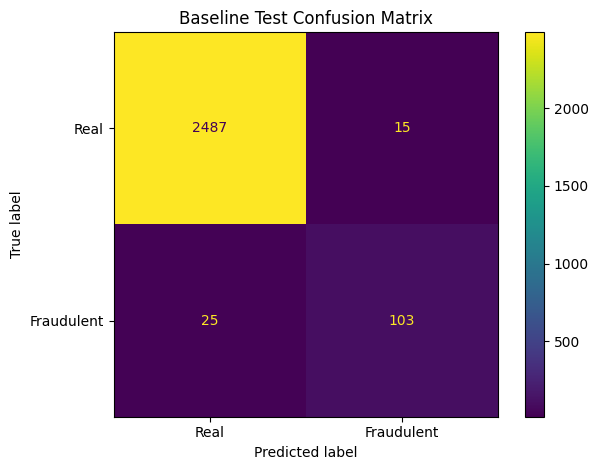

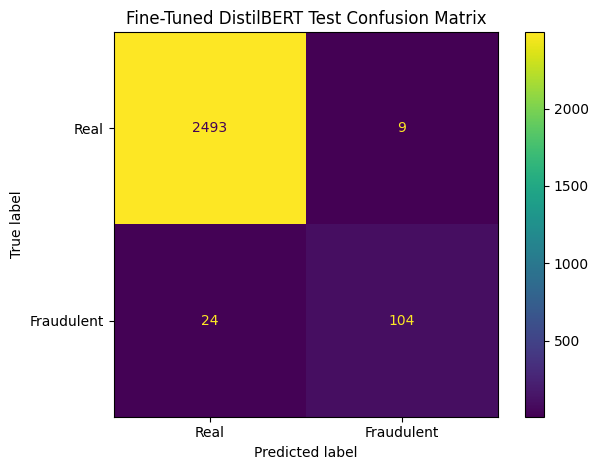

In [ ]:
# Classification reports and confusion matrices.
print("Baseline classification report")
print(
    classification_report(
        test_df["label"],
        baseline_test_predictions,
        target_names=["Real", "Fraudulent"],
        digits=4,
        zero_division=0,
    )
)

print("DistilBERT classification report")
print(
    classification_report(
        bert_test_result["labels"],
        bert_test_predictions,
        target_names=["Real", "Fraudulent"],
        digits=4,
        zero_division=0,
    )
)

ConfusionMatrixDisplay.from_predictions(
    test_df["label"],
    baseline_test_predictions,
    display_labels=["Real", "Fraudulent"],
    values_format="d",
)
plt.title("Baseline Test Confusion Matrix")
plt.tight_layout()
plt.show()

ConfusionMatrixDisplay.from_predictions(
    bert_test_result["labels"],
    bert_test_predictions,
    display_labels=["Real", "Fraudulent"],
    values_format="d",
)
plt.title("Fine-Tuned DistilBERT Test Confusion Matrix")
plt.tight_layout()
plt.show()

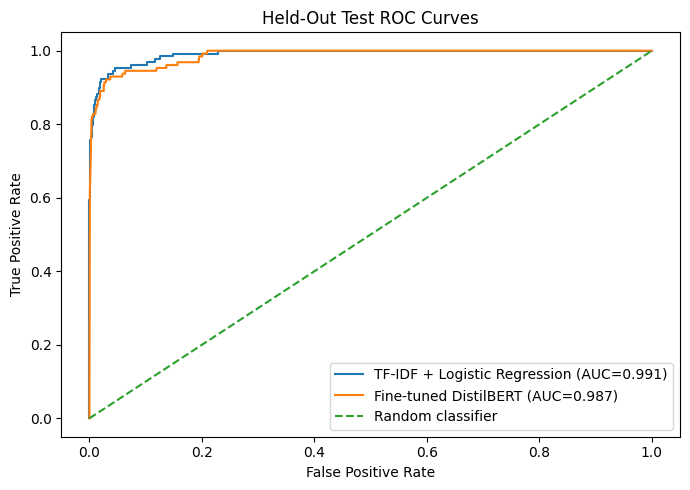

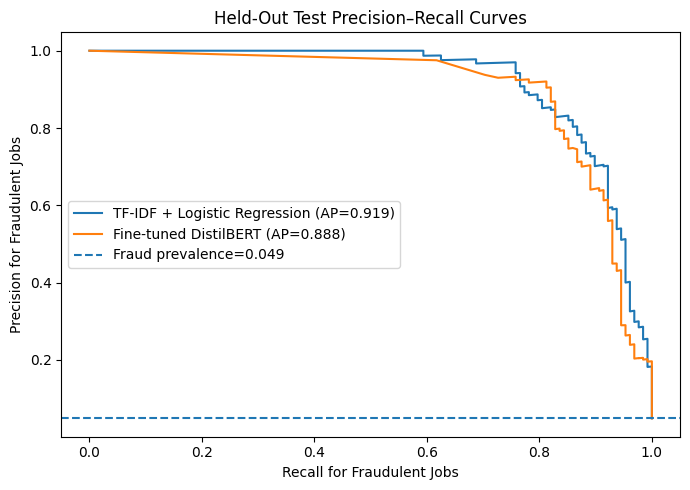

In [ ]:
# ROC and precision-recall curves.
baseline_fpr, baseline_tpr, _ = roc_curve(
    test_df["label"],
    baseline_test_probabilities,
)
bert_fpr, bert_tpr, _ = roc_curve(
    bert_test_result["labels"],
    bert_test_result["probabilities"],
)

plt.figure(figsize=(7, 5))
plt.plot(
    baseline_fpr,
    baseline_tpr,
    label=(
        "TF-IDF + Logistic Regression "
        f"(AUC={baseline_metrics['roc_auc']:.3f})"
    ),
)
plt.plot(
    bert_fpr,
    bert_tpr,
    label=(
        "Fine-tuned DistilBERT "
        f"(AUC={bert_metrics['roc_auc']:.3f})"
    ),
)
plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
plt.title("Held-Out Test ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

baseline_precision_curve, baseline_recall_curve, _ = precision_recall_curve(
    test_df["label"],
    baseline_test_probabilities,
)
bert_precision_curve, bert_recall_curve, _ = precision_recall_curve(
    bert_test_result["labels"],
    bert_test_result["probabilities"],
)

positive_prevalence = test_df["label"].mean()
plt.figure(figsize=(7, 5))
plt.plot(
    baseline_recall_curve,
    baseline_precision_curve,
    label=(
        "TF-IDF + Logistic Regression "
        f"(AP={baseline_metrics['average_precision']:.3f})"
    ),
)
plt.plot(
    bert_recall_curve,
    bert_precision_curve,
    label=(
        "Fine-tuned DistilBERT "
        f"(AP={bert_metrics['average_precision']:.3f})"
    ),
)
plt.axhline(
    positive_prevalence,
    linestyle="--",
    label=f"Fraud prevalence={positive_prevalence:.3f}",
)
plt.title("Held-Out Test Precision–Recall Curves")
plt.xlabel("Recall for Fraudulent Jobs")
plt.ylabel("Precision for Fraudulent Jobs")
plt.legend()
plt.tight_layout()
plt.show()

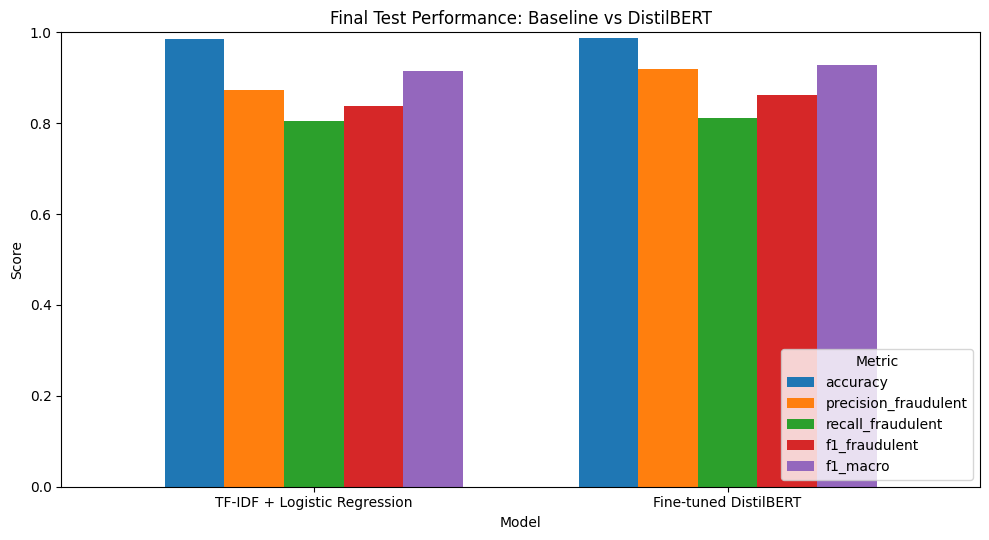

Fraudulent F1 difference (DistilBERT - baseline): +0.0257
Macro F1 difference (DistilBERT - baseline): +0.0135


In [ ]:
# Direct visual comparison of minority-class metrics.
comparison_columns = [
    "accuracy",
    "precision_fraudulent",
    "recall_fraudulent",
    "f1_fraudulent",
    "f1_macro",
]

ax = comparison[comparison_columns].plot(
    kind="bar",
    figsize=(10, 5.5),
    width=0.72,
)
ax.set_title("Final Test Performance: Baseline vs DistilBERT")
ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Metric", loc="lower right")
plt.tight_layout()
plt.show()

print(
    "Fraudulent F1 difference (DistilBERT - baseline):",
    f"{bert_metrics['f1_fraudulent'] - baseline_metrics['f1_fraudulent']:+.4f}",
)
print(
    "Macro F1 difference (DistilBERT - baseline):",
    f"{bert_metrics['f1_macro'] - baseline_metrics['f1_macro']:+.4f}",
)

## 16. Error analysis



In [ ]:
# Build a row-level test prediction table and inspect confident errors.
test_predictions_df = test_df.copy()
test_predictions_df["true_label"] = test_predictions_df["label"].map(LABEL_NAMES)
test_predictions_df["predicted_id"] = bert_test_predictions
test_predictions_df["predicted_label"] = test_predictions_df[
    "predicted_id"
].map(LABEL_NAMES)
test_predictions_df["fraudulent_probability"] = bert_test_result[
    "probabilities"
]
test_predictions_df["correct"] = (
    test_predictions_df["label"] == test_predictions_df["predicted_id"]
)

test_predictions_df["error_type"] = np.select(
    [
        (test_predictions_df["label"] == 1)
        & (test_predictions_df["predicted_id"] == 0),
        (test_predictions_df["label"] == 0)
        & (test_predictions_df["predicted_id"] == 1),
    ],
    ["False negative", "False positive"],
    default="Correct",
)

false_negatives = (
    test_predictions_df[test_predictions_df["error_type"] == "False negative"]
    .sort_values("fraudulent_probability", ascending=True)
    .head(10)
    .copy()
)
false_positives = (
    test_predictions_df[test_predictions_df["error_type"] == "False positive"]
    .sort_values("fraudulent_probability", ascending=False)
    .head(10)
    .copy()
)

for frame in [false_negatives, false_positives]:
    frame["text_preview"] = frame["text"].str.slice(0, 500)

print("Most confident false negatives")
display(
    false_negatives[
        [
            "true_label",
            "predicted_label",
            "fraudulent_probability",
            "text_preview",
        ]
    ]
)

print("Most confident false positives")
display(
    false_positives[
        [
            "true_label",
            "predicted_label",
            "fraudulent_probability",
            "text_preview",
        ]
    ]
)

Most confident false negatives


,true_label,predicted_label,fraudulent_probability,text_preview
1668,Fraudulent,Real,0.000540,Title: Sales Representative Company profile: S...
1837,Fraudulent,Real,0.000564,Title: Hotel Workers Needed Company profile: H...
69,Fraudulent,Real,0.000583,Title: Credit and Collections Clerk Company pr...
1467,Fraudulent,Real,0.000585,Title: Junior Engineer/Engineering Technician ...
1735,Fraudulent,Real,0.000700,Title: Customer Service Specialist Description...
1776,Fraudulent,Real,0.000806,Title: Payroll Clerk Company profile: Basil Li...
2162,Fraudulent,Real,0.000953,Title: Marketing/sales Coordinator Description...
1362,Fraudulent,Real,0.002178,Title: Business Development Manager Descriptio...
512,Fraudulent,Real,0.002512,Title: Customer service/ Data Entry Descriptio...
1876,Fraudulent,Real,0.004135,Title: Software Design Engineer Description: S...


Most confident false positives


,true_label,predicted_label,fraudulent_probability,text_preview
131,Real,Fraudulent,0.999512,Title: Data Entry/Customer Service Rep Descrip...
282,Real,Fraudulent,0.999512,Title: Part-Time Administrative/Data Entry I D...
1140,Real,Fraudulent,0.999023,Title: Admin Assistant Description: This is an...
1559,Real,Fraudulent,0.999023,Title: Administrative Assistant Description: O...
1752,Real,Fraudulent,0.999023,Title: Office PA/Receptionist Description: Job...
2001,Real,Fraudulent,0.999023,Title: Receptionist - Wellness Practice Descri...
1911,Real,Fraudulent,0.998535,Title: Executive Administrative Assistant Desc...
1991,Real,Fraudulent,0.997070,Title: Part-Time Finance Assistant Description...
2186,Real,Fraudulent,0.982910,Title: Hiring for all FOH and BOH Positions! D...


## 17. Predict new job advertisements


In [ ]:
# Inference function for unseen job-ad text.
def predict_job_advertisement(job_text: str) -> pd.DataFrame:
    cleaned_text = clean_fragment(job_text)
    if len(cleaned_text) < 10:
        raise ValueError("Please provide a meaningful job-advertisement text.")

    # Baseline probability
    baseline_features = tfidf.transform([cleaned_text])
    baseline_probability = baseline_model.predict_proba(baseline_features)[0, 1]
    baseline_prediction = int(baseline_probability >= baseline_threshold)

    # DistilBERT probability
    encoded = tokenizer(
        cleaned_text,
        return_tensors="pt",
        truncation=True,
        max_length=CFG.max_length,
    )
    encoded = {
        key: value.to(DEVICE)
        for key, value in encoded.items()
        if key in {"input_ids", "attention_mask"}
    }

    best_model.eval()
    with torch.no_grad():
        outputs = best_model(**encoded)
        bert_probability = torch.softmax(outputs.logits, dim=1)[0, 1].item()
    bert_prediction = int(bert_probability >= bert_threshold)

    return pd.DataFrame([
        {
            "model": "TF-IDF + Logistic Regression",
            "fraudulent_probability": baseline_probability,
            "decision_threshold": baseline_threshold,
            "predicted_label": LABEL_NAMES[baseline_prediction],
        },
        {
            "model": "Fine-tuned DistilBERT",
            "fraudulent_probability": bert_probability,
            "decision_threshold": bert_threshold,
            "predicted_label": LABEL_NAMES[bert_prediction],
        },
    ])


example_job_text = """
Title: Junior Data Analyst. Description: Analyse business data and prepare dashboards.
Requirements: Python, SQL and communication skills. The company provides a verifiable office
address and conducts interviews through its official corporate email domain.
"""

display(predict_job_advertisement(example_job_text).round(4))

,model,fraudulent_probability,decision_threshold,predicted_label
0,TF-IDF + Logistic Regression,0.2030,0.56,Real
1,Fine-tuned DistilBERT,0.0081,0.85,Real


## 18. Save reproducibility artefacts




In [ ]:

results_path = Path(CFG.results_dir)
results_path.mkdir(parents=True, exist_ok=True)

split_summary.to_csv(results_path / "split_summary.csv", index=False)
missing_summary.to_csv(results_path / "missing_summary.csv")
baseline_tuning.to_csv(results_path / "baseline_tuning.csv", index=False)
transformer_tuning.to_csv(results_path / "transformer_tuning.csv", index=False)
history_df.to_csv(results_path / "training_history.csv", index=False)
comparison.to_csv(results_path / "final_model_comparison.csv")
baseline_threshold_table.to_csv(
    results_path / "baseline_threshold_tuning.csv",
    index=False,
)
bert_threshold_table.to_csv(
    results_path / "distilbert_threshold_tuning.csv",
    index=False,
)
test_predictions_df.to_csv(
    results_path / "distilbert_test_predictions.csv",
    index=False,
)

joblib.dump(tfidf, results_path / "tfidf_vectorizer.joblib")
joblib.dump(baseline_model, results_path / "logistic_regression.joblib")

with open(results_path / "experiment_config.json", "w", encoding="utf-8") as file:
    json.dump(asdict(CFG), file, indent=2)

with open(results_path / "selected_settings.json", "w", encoding="utf-8") as file:
    json.dump(
        {
            "best_baseline_C": best_c,
            "best_transformer_params": best_transformer_params,
            "best_epoch": best_epoch,
            "baseline_threshold": baseline_threshold,
            "distilbert_threshold": bert_threshold,
            "class_weights": class_weights_array.tolist(),
            "token_sample_truncated_percent": truncated_percentage,
        },
        file,
        indent=2,
    )

zip_path = shutil.make_archive(
    "/content/fake_job_assignment_results",
    "zip",
    CFG.results_dir,
)

print("Lightweight results ZIP:", zip_path)
print("DistilBERT checkpoint directory:", CFG.output_dir)

Lightweight results ZIP: /content/fake_job_assignment_results.zip
DistilBERT checkpoint directory: /content/distilbert_fake_job_best
